Original Data:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies      

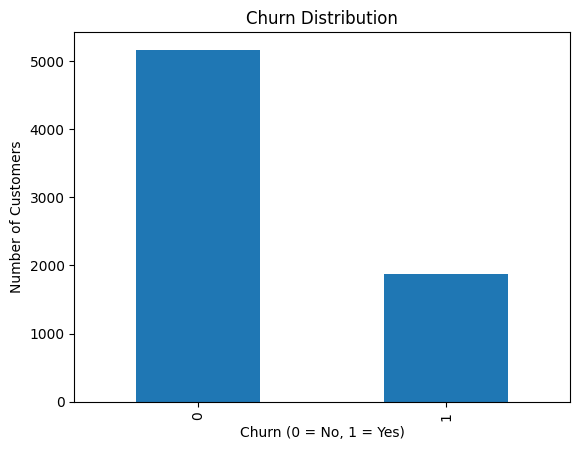

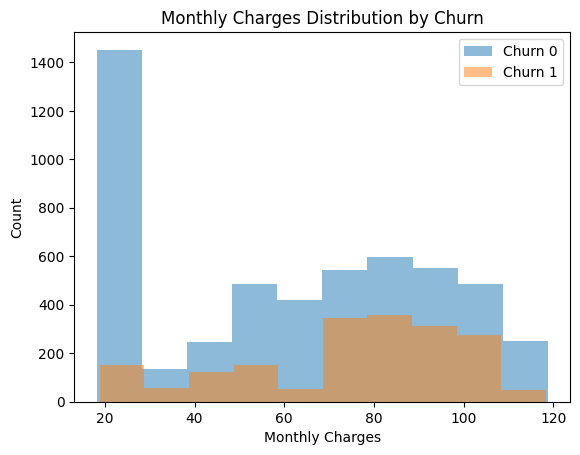

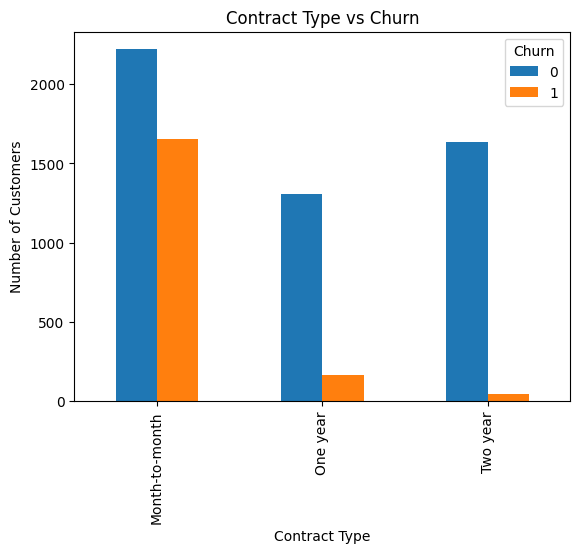

In [3]:
#Data Visualization from Extraction Transformation and Loading (ETL) Process.

import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv('Telco-Customer-Churn3.csv')#extraction

print("Original Data:")
print(data.head())


# Remove customerID (not useful for analysis) transformation
data = data.drop(columns=['customerID'])

# Convert TotalCharges to numeric (it may contain spaces)
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

# Remove missing values
data = data.dropna()

# Convert Churn to numeric (Yes=1, No=0)
data['Churn'] = data['Churn'].map({'Yes': 1, 'No': 0})

print("\nCleaned Data:")
print(data.head())


# Save cleaned data 
data.to_csv('cleaned_telco_data.csv', index=False)#load 

#visualization
#1. Churn Count
churn_count = data['Churn'].value_counts()

plt.figure()
churn_count.plot(kind='bar')

plt.title("Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.show()

#Monthly Charges vs Churn
plt.figure()

for churn_value in data['Churn'].unique():
    subset = data[data['Churn'] == churn_value]
    plt.hist(subset['MonthlyCharges'], alpha=0.5, label=f'Churn {churn_value}')

plt.title("Monthly Charges Distribution by Churn")
plt.xlabel("Monthly Charges")
plt.ylabel("Count")
plt.legend()

plt.show()

#3. Contract Type vs Churn
contract_churn = pd.crosstab(data['Contract'], data['Churn'])

contract_churn.plot(kind='bar')

plt.title("Contract Type vs Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()